# VES Inversion Visualization
Grid Search dan PSO untuk Vertical Electrical Sounding (VES)

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Model Bumi Sintetik

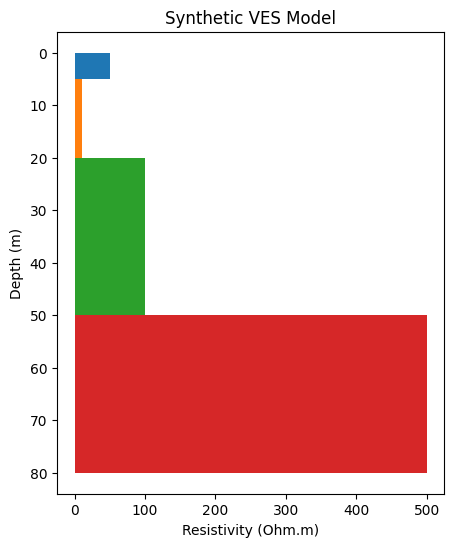

In [2]:
rho = [50,10,100,500]
depth = [0,5,20,50,80]
plt.figure(figsize=(5,6))
for i in range(len(rho)):
    plt.fill_betweenx([depth[i], depth[i+1]],0,rho[i])
plt.gca().invert_yaxis()
plt.xlabel('Resistivity (Ohm.m)')
plt.ylabel('Depth (m)')
plt.title('Synthetic VES Model')
plt.show()


## 2. Kurva VES Sintetik

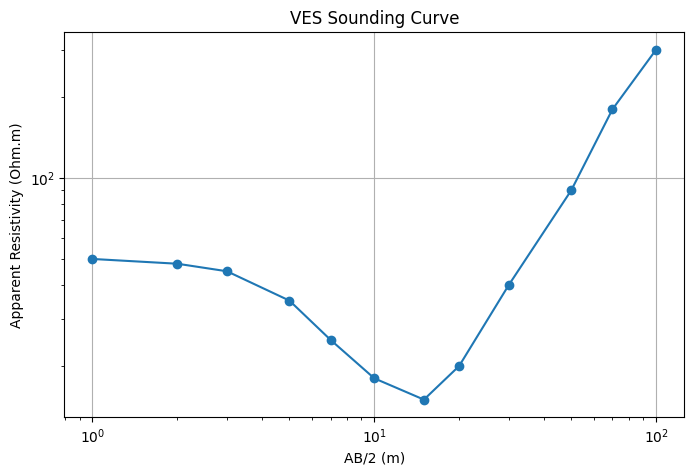

In [3]:
AB2 = np.array([1,2,3,5,7,10,15,20,30,50,70,100])
rho_obs = np.array([50,48,45,35,25,18,15,20,40,90,180,300])
plt.figure(figsize=(8,5))
plt.loglog(AB2,rho_obs,'o-')
plt.xlabel('AB/2 (m)')
plt.ylabel('Apparent Resistivity (Ohm.m)')
plt.title('VES Sounding Curve')
plt.grid(True)
plt.show()


## 3. Menambahkan Noise

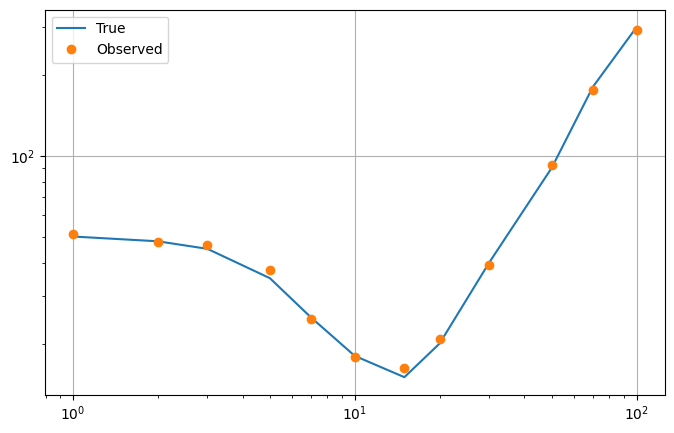

In [4]:
np.random.seed(42)
noise = np.random.normal(0,0.05*rho_obs)
rho_noisy = rho_obs + noise
plt.figure(figsize=(8,5))
plt.loglog(AB2,rho_obs,label='True')
plt.loglog(AB2,rho_noisy,'o',label='Observed')
plt.legend()
plt.grid()
plt.show()


## 4. Misfit Surface Grid Search

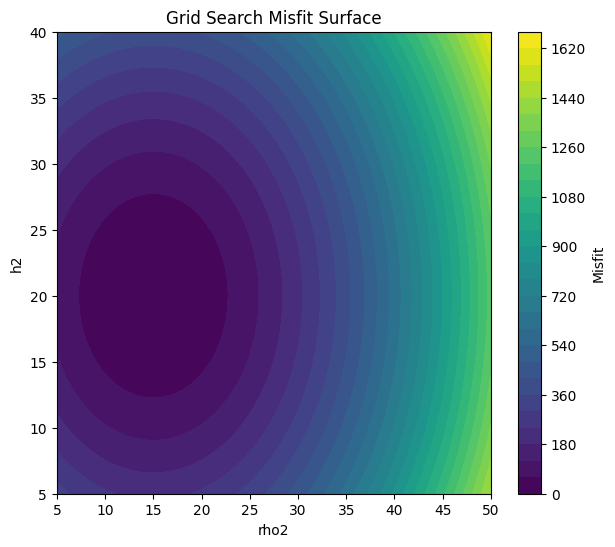

In [5]:
rho2 = np.linspace(5,50,100)
h2 = np.linspace(5,40,100)
R,H = np.meshgrid(rho2,h2)
misfit = (R-15)**2 + (H-20)**2
plt.figure(figsize=(7,6))
plt.contourf(R,H,misfit,30)
plt.colorbar(label='Misfit')
plt.xlabel('rho2')
plt.ylabel('h2')
plt.title('Grid Search Misfit Surface')
plt.show()


## 5. Simulasi Pergerakan Partikel PSO

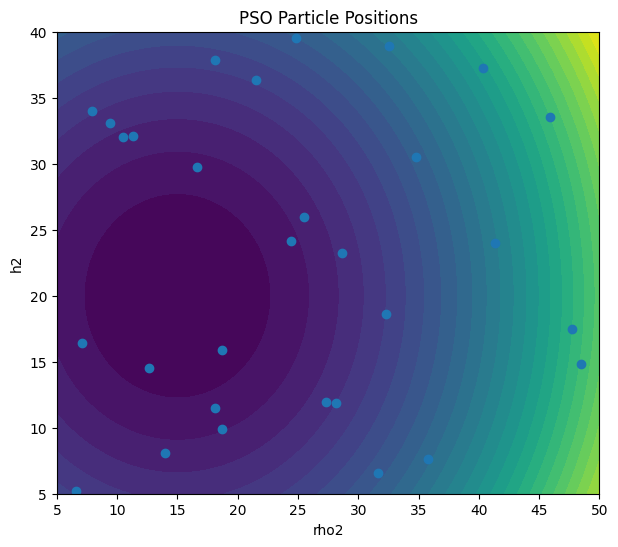

In [6]:
particles_x = np.random.uniform(5,50,30)
particles_y = np.random.uniform(5,40,30)
plt.figure(figsize=(7,6))
plt.contourf(R,H,misfit,30)
plt.scatter(particles_x,particles_y)
plt.xlabel('rho2')
plt.ylabel('h2')
plt.title('PSO Particle Positions')
plt.show()


## 6. Kurva Konvergensi PSO

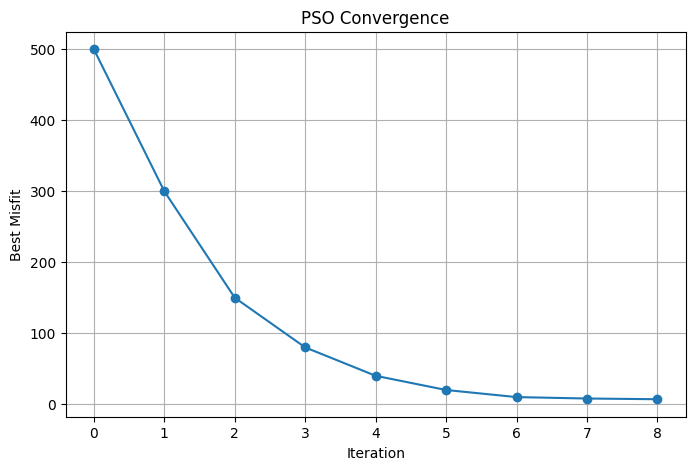

In [7]:
misfit_history = [500,300,150,80,40,20,10,8,7]
plt.figure(figsize=(8,5))
plt.plot(misfit_history,marker='o')
plt.xlabel('Iteration')
plt.ylabel('Best Misfit')
plt.title('PSO Convergence')
plt.grid()
plt.show()


## 7. Observed vs Calculated

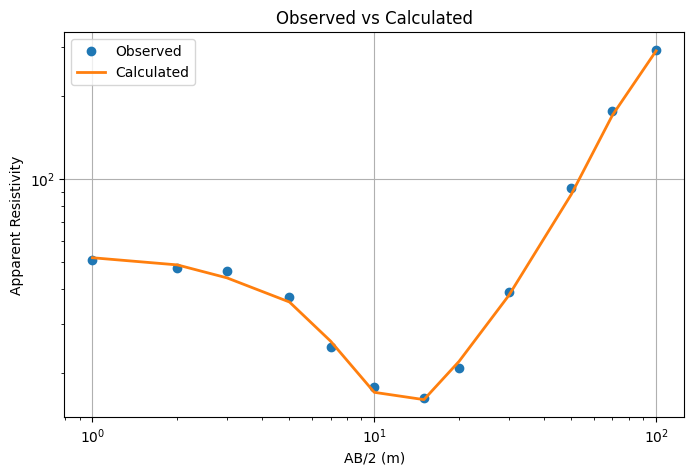

In [8]:
rho_calc = np.array([52,49,44,36,26,17,16,22,38,88,170,290])
plt.figure(figsize=(8,5))
plt.loglog(AB2,rho_noisy,'o',label='Observed')
plt.loglog(AB2,rho_calc,'-',linewidth=2,label='Calculated')
plt.xlabel('AB/2 (m)')
plt.ylabel('Apparent Resistivity')
plt.title('Observed vs Calculated')
plt.legend()
plt.grid()
plt.show()
